In [161]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import pandas as pd

In [184]:
SMALL_SIZE = 18
MEDIUM_SIZE = 18
BIGGER_SIZE = 22

plt.rc('font', size=BIGGER_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE) 


lts = ['-', '--', '-.',':', '-']


steps = ['0.2', '0.05']

names = ['CLs.npy',
'CNs.npy',
'CTs.npy',
'YLs.npy',
'YNs.npy',
'YTs.npy',
'mLs.npy',
'mNs.npy',
'mTs.npy']

def mean_dist_true(m_true, Y):
    d, n = Y.shape
    running_mean = Y[:, 0]
    conv = np.zeros(n)
    conv[0] = np.power(np.linalg.norm(running_mean - m_true), 2)
    for i in range(n-1):
        running_mean = (i+1) * running_mean / (i+2) + (1) * Y[:, i] / (i+2)
        conv[i+1] = np.power(np.linalg.norm(running_mean - m_true), 2)
    return conv

sm = 10

In [170]:
YNs = np.load(steps[0] + '/' + 'YNs.npy')

d, N, reps = YNs.shape
N2 = sm * N
convL = np.zeros((sm * N, len(steps)))
convN = np.zeros((N, len(steps)))
convT = np.zeros((sm * N, len(steps)))
i = 0

for s in steps:
    YNs = np.load(s + '/' + 'YNs.npy')
    YLs = np.load(s + '/' + 'YLs.npy')
    YTs = np.load(s + '/' + 'YTs.npy')
    
    for r in range(reps):
        print(r)
        convN[:, i] += mean_dist_true(np.zeros((d,)), YNs[:,:,r]) / reps
        convL[:, i] += mean_dist_true(np.zeros((d,)), YLs[:,:,r]) / reps
        convT[:, i] += mean_dist_true(np.zeros((d,)), YTs[:,:,r]) / reps
    
    i += 1
    

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


In [171]:
np.save('plot_data/convN_mean.npy', convN)
np.save('plot_data/convL_mean.npy', convL)
np.save('plot_data/convT_mean.npy', convT)

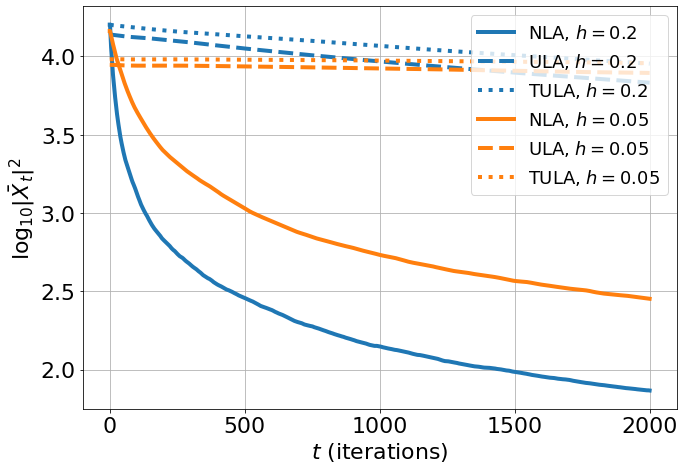

In [194]:
convN = np.load('plot_data/convN_mean.npy')
convL = np.load('plot_data/convL_mean.npy')
convT = np.load('plot_data/convT_mean.npy')

p, ax = plt.subplots(figsize = (10, 7))

colors = ['tab:blue',"tab:orange"]
i = 0
idx = [0,1]
for i in idx:
    s = steps[i]
    ax.plot(np.log10(convN[0:N,i]), color = colors[i], linestyle = lts[0], label = r'NLA, $h=$' + s, linewidth = 4)
    ax.plot(np.log10(convL[0:N,i]), color = colors[i], linestyle = lts[1], label = r'ULA, $h=$' + s, linewidth = 4)
    ax.plot(np.log10(convT[0:N,i]), color = colors[i], linestyle = lts[3], label = r'TULA, $h=$' + s, linewidth = 4)
    
    i += 1
    
handles, labels = ax.get_legend_handles_labels() 
ax.legend(loc='upper right')
plt.xlabel(r'$t$ (iterations)')    
plt.ylabel(r'$\log_{10} \|\bar X_t\|^2$')   
ax.grid(b = True)
plt.tight_layout()

plt.savefig('gen_mvg_mean_iters_legend.pdf')

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


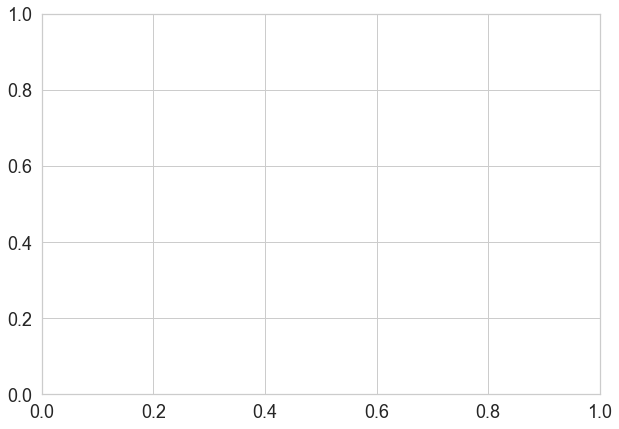

In [68]:
#plt.figure(figsize = (10, 7))
p, ax = plt.subplots(figsize = (10, 7))
i = 0

steps = ['0.7', '0.5', '0.2', '0.1']

YNs = np.load('0.7' + '/' + 'YNs.npy')
d, N, reps = YNs.shape
convL = np.zeros((sm * N, len(steps)))
convN = np.zeros((N, len(steps)))
convT = np.zeros((sm * N, len(steps)))
i = 0
tL = np.zeros((sm * N, len(steps)))
tN = np.zeros((N, len(steps)))
tT = np.zeros((sm * N, len(steps)))
for s in steps:
    YNs = np.load(s + '/' + 'YNs.npy')
    YLs = np.load(s + '/' + 'YLs.npy')
    YTs = np.load(s + '/' + 'YTs.npy')
    
    tLs = np.load(s + '/' + 'tLs.npy')
    tNs = np.load(s + '/' + 'tNs.npy')
    tTs = np.load(s + '/' + 'tTs.npy')
    tLs = tLs - np.outer(np.ones((sm * N,)), tLs[0,:])
    tNs = tNs - np.outer(np.ones((N,)), tNs[0,:])
    tTs = tTs - np.outer(np.ones((sm * N,)), tTs[0,:])
    tL[:, i] = np.mean(tLs, 1)
    tN[:, i] = np.mean(tNs, 1)
    tT[:, i] = np.mean(tTs, 1)
    
    
    
    for r in range(reps):
        print(r)
        convN[:, i] += mean_dist_true(np.zeros((d,)), YNs[:,:,r]) / reps
        convL[:, i] += mean_dist_true(np.zeros((d,)), YLs[:,:,r]) / reps
        convT[:, i] += mean_dist_true(np.zeros((d,)), YTs[:,:,r]) / reps
    
    
    
    i += 1

In [ ]:
p, ax = plt.subplots(figsize = (10, 7))

colors = ['tab:blue', "tab:olive", "tab:purple", "tab:orange"]
i = 0
idx = [0, 3]
for i in idx:
    s = steps[i]
    ax.plot(np.log10(convN[0:N,i]), color = colors[i], linestyle = lts[0], label = r'NLA, $h=$' + s, linewidth = 4)
    ax.plot(np.log10(convL[0:N,i]), color = colors[i], linestyle = lts[1], label = r'ULA, $h=$' + s, linewidth = 4)
    ax.plot(np.log10(convT[0:N,i]), color = colors[i], linestyle = lts[3], label = r'TULA, $h=$' + s, linewidth = 4)
    
    i += 1
    
handles, labels = ax.get_legend_handles_labels() 
ax.legend()
plt.xlabel(r'$t$ (iterations)')    
plt.ylabel(r'$\log_{10} \|\bar X_t\|^2$')   
ax.grid(b = True)




    ax.plot(tN, np.log10(convN), 'b', linestyle = lts[i], label = r'NLA, $h=$' + s)
    ax.plot(tL, np.log10(convL), 'r', linestyle = lts[i], label = r'ULA, $h=$' + s)
    ax.plot(tT, np.log10(convT), 'g', linestyle = lts[i], label = r'TULA, $h=$' + s)    
handles, labels = ax.get_legend_handles_labels()    
ax.legend([handles[i] for i in [0,3,6,9,1,4,7,10,2,5,8,11]], 
          [labels[i] for i in [0,3,6,9,1,4,7,10,2,5,8,11]])    
plt.xlabel(r'$t$ (sec)')    
plt.grid()
plt.ylabel(r'$\log_{10} \|\bar X_t\|^2$')    
plt.savefig('mvg_mean_seconds.pdf')

In [ ]:
YNs = np.load(s + '/' + 'YNs.npy')
YLs = np.load(s + '/' + 'YLs.npy')
YTs = np.load(s + '/' + 'YTs.npy')

convL = np.zeros(1000)
convN = np.zeros(1000)
convT = np.zeros(1000)
for r in range(reps):
    convN += mean_dist_true(np.zeros((5,)), YNs[:,:,r]) / reps
    convL += mean_dist_true(np.zeros((5,)), YLs[:,:,r]) / reps
    convT += mean_dist_true(np.zeros((5,)), YTs[:,:,r]) / reps
    
plt.figure(figsize = (7, 7))
plt.title('step size' + s)
plt.plot(np.log10(convN), 'b', linestyle = '-')
plt.plot(np.log10(convL), 'r')
plt.plot(np.log10(convT), 'g')
plt.legend(['NLA', 'ULA', 'TULA'])

plt.legend('--', '0.5')

In [10]:
s = '0.7'
YNs = np.load(s + '/' + 'YNs.npy')
YLs = np.load(s + '/' + 'YLs.npy')
YTs = np.load(s + '/' + 'YTs.npy')
    
d, N, reps = YNs.shape
d, N2, _ = YLs.shape
convL = np.zeros(N2)
convN = np.zeros(N)
convT = np.zeros(N2)
for r in range(reps):
    convN += mean_dist_true(np.zeros((d,)), YNs[:,:,r]) / reps
    convL += mean_dist_true(np.zeros((d,)), YLs[:,:,r]) / reps
    convT += mean_dist_true(np.zeros((d,)), YTs[:,:,r]) / reps

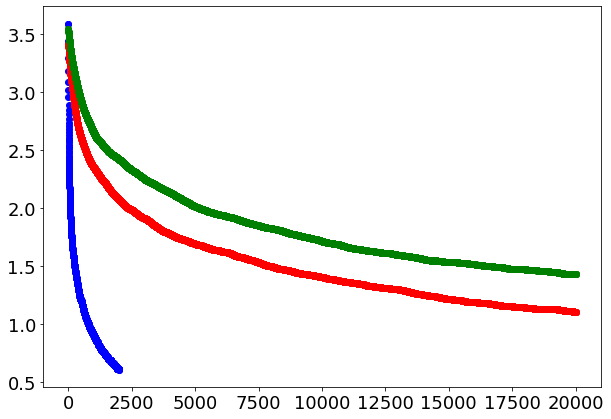

In [11]:
p, ax = plt.subplots(figsize = (10, 7))
    
ax.plot(np.log10(convN), 'bo', label = r'NLA, $h=$' + s)
ax.plot(np.log10(convL), 'ro', label = r'ULA, $h=$' + s)
ax.plot(np.log10(convT), 'go', label = r'TULA, $h=$' + s)

In [12]:
lcn = np.log10(convN)
lcl = np.log10(convL)
lct = np.log10(convT)

errors = [3, 2.5, 2.0, 1.5]
ieN = np.zeros(len(errors))
ieL = np.zeros(len(errors))
ieT = np.zeros(len(errors))
i = 0
for e in errors:
    ieN[i] = next(x for x, val in enumerate(lcn) if val <e)
    ieL[i] = next(x for x, val in enumerate(lcl) if val <e)
    ieT[i] = next(x for x, val in enumerate(lct) if val <e)
    i += 1
    

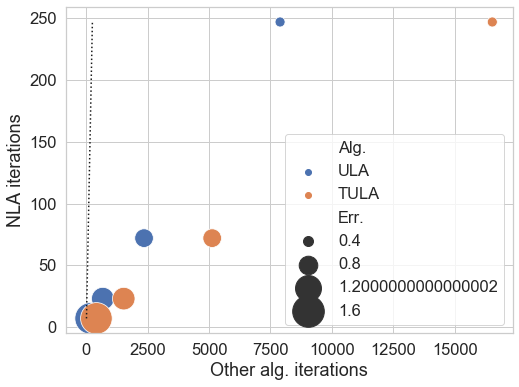

In [13]:
import seaborn as sns; sns.set()
import pandas as pd

#rc('font',**{'family':'serif','serif':['Avenir']})


df = pd.DataFrame({'NLA iterations':np.append(ieN, (ieN)), "Other alg. iterations": np.append(ieL,(ieT)), 
                   "Alg.": ["ULA", "ULA", "ULA", "ULA", "TULA", "TULA", "TULA", "TULA"], 
                  "Err.": [1.6, 1.0, 0.8, 0.5, 1.6, 1.0, 0.8, 0.5]})

# sns.scatterplot(ieN, errors)
# sns.scatterplot(ieL, errors)
# sns.scatterplot(ieT, errors)
# sns.ylabel(r'$\log_{10} (\| X_t \|^2) $')
# sns.xlabel(r'# iterations')
sns.set(font_scale=1.5)  # crazy big
sns.set_style("whitegrid")
# plt.rcParams['font.family'] = 'Helvetica'

plt.figure(figsize = (8, 6))
ax = sns.scatterplot(x = "Other alg. iterations", y = "NLA iterations", data = df, size="Err.", sizes=(100, 1000), hue = "Alg.", s = 120)
plt.plot(ieN, ieN, 'k:')
#plt.title()
#sns.legend()
#sns.grid()
#sns.ylabel(r'# iterations other')
#sns.xlabel(r'# iterations Newton')
#plt.xlim([0, 10000])
#plt.axis('equal')

plt.savefig('iter_vs_iter_mvg_001.pdf')

In [39]:
s = '0.7'
YNs = np.load(s + '/' + 'YNs.npy')
YLs = np.load(s + '/' + 'YLs.npy')
YTs = np.load(s + '/' + 'YTs.npy')
    
d, N, reps = YNs.shape
d, N2, _ = YLs.shape
convL = np.zeros(N2)
convN = np.zeros(N)
convT = np.zeros(N2)
for r in range(reps):
    convN += mean_dist_true(np.zeros((d,)), YNs[:,:,r]) / reps
    convL += mean_dist_true(np.zeros((d,)), YLs[:,:,r]) / reps
    convT += mean_dist_true(np.zeros((d,)), YTs[:,:,r]) / reps

lcn = np.log10(convN)
lcl = np.log10(convL)
lct = np.log10(convT)

# errors = [3, 2.5, 2.0]
errors = [3, 2.5, 2.0, 1.75, 1.5]
ieN = np.zeros(len(errors))
ieL = np.zeros(len(errors))
ieT = np.zeros(len(errors))
i = 0
for e in errors:
    ieN[i] = next(x for x, val in enumerate(lcn) if val <e)
    ieL[i] = next(x for x, val in enumerate(lcl) if val <e)
    ieT[i] = next(x for x, val in enumerate(lct) if val <e)
    i += 1
    


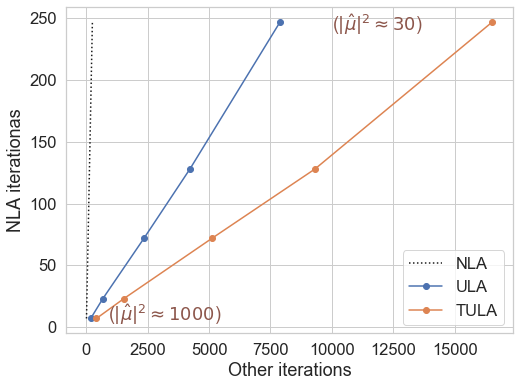

In [40]:

plt.figure(figsize = (8, 6))

plt.plot(ieN, ieN, 'k:')
plt.plot(ieL, ieN, 'o-')
plt.plot(ieT, ieN, 'o-')
plt.legend(['NLA', 'ULA', 'TULA'])
plt.ylabel("NLA iterationas")
plt.xlabel("Other iterations")
plt.text(10000, 240, r'($\| \hat \mu\|^2 \approx 30$)', c = 'tab:brown')
plt.text(900, 5, r'($\| \hat \mu\|^2 \approx 1000 $)', c = 'tab:brown')

plt.savefig('iter_vs_iter_mean_mvg_07.pdf')

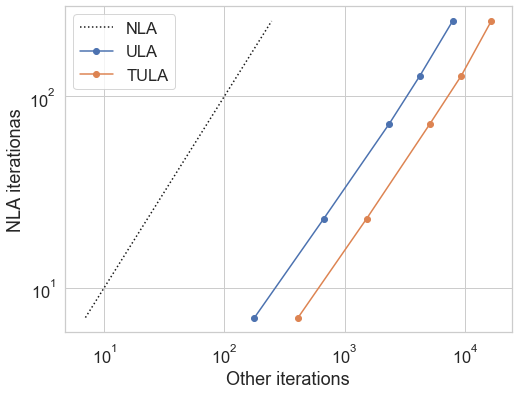

In [21]:
plt.figure(figsize = (8, 6))

plt.plot(ieN, ieN, 'k:')
plt.plot(ieL, ieN, 'o-')
plt.plot(ieT, ieN, 'o-')
plt.legend(['NLA', 'ULA', 'TULA'])
plt.ylabel("NLA iterationas")
plt.xlabel("Other iterations")
plt.yscale('log')
plt.xscale('log')
# plt.text(10000, 240, r'($err \approx 1000$)', c = 'tab:brown')
# plt.text(700, 5, r'($err \approx 30 $)', c = 'tab:brown')

plt.savefig('iter_vs_iter_mean_mvg_07.pdf')

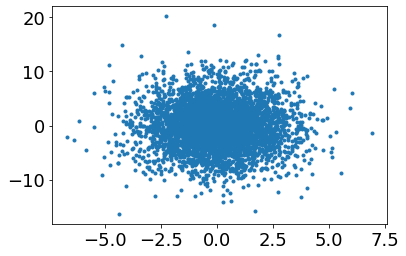

In [20]:
plt.plot(YNs[0,:,0], YNs[1,:,0], '.')

In [174]:
from tqdm import tqdm
from scipy.linalg import inv
import math
def calc_scatter(X, u, Sigma):
    if len(X.shape) == 1:
        d = X.size
        n = 1
    else:
        d, n = X.shape
    S = Sigma
    Y = X.copy()
    for i in (range(50)):
        Y = X * np.outer(np.ones((d,)), u(np.sum(X*(inv(S).dot(X)), axis = 0)))
        S = Y.dot(X.T) / n   
    return S

p = 3/4
def u(x):
    return ((p * (np.power(x, (p-1)))) * 2)


In [175]:
def cov_dist_true(C_true, Y, u):
    d, n = Y.shape
    running_cov = calc_scatter(Y[:, 0:(2*d)], u, Sigma)
    conv = np.zeros(int(n/(2 * d)))
    i = 2 * d
    j = 0
    while i < n:
        running_cov = calc_scatter(Y[:, 0:i], u, Sigma)
        conv[j] = np.power(np.linalg.norm(running_cov - C_true), 2) / np.power(np.linalg.norm(Sigma), 2)
        i += 2 * d
        j += 1
        #print(i)
        
    return conv
# def cov_dist_true(C_true, Y, u):
#     d, n = Y.shape
#     running_cov = np.outer(Y[:, 0], Y[:, 0])
#     conv = np.zeros(n)
#     conv[0] = np.power(np.linalg.norm(running_cov - C_true), 2) / np.power(np.linalg.norm(Sigma), 2)
#     for i in range(n-1):
#         running_cov = (i+1) * running_cov / (i+2) + (1) * np.outer(Y[:, i], Y[:, i]) / (i+2)
#         conv[i+1] = np.power(np.linalg.norm(running_cov - C_true), 2)/ np.power(np.linalg.norm(Sigma), 2)
#     return conv

In [176]:
YNs = np.load(steps[0] + '/' + 'YNs.npy')

d, N, reps = YNs.shape
num = int(N/(2*d))

N2 = sm * N
convL = np.zeros((num, len(steps)))
convN = np.zeros((num, len(steps)))
convT = np.zeros((num, len(steps)))
i = 0
for i in [0,1]:
    s = steps[i]
    YNs = np.load(s + '/' + 'YNs.npy')
    YLs = np.load(s + '/' + 'YLs.npy')
    YLs = YLs[:,0:N,:]
    YTs = np.load(s + '/' + 'YTs.npy')
    YTs = YTs[:,0:N,:]

    Sigma = np.load(s + '/' + 'Sigma.npy')

    
    for r in tqdm(range(reps)):
        #print(r)
        convN[:, i] += cov_dist_true(Sigma, YNs[:,:,r], u) / reps
        convL[:, i] += cov_dist_true(Sigma, YLs[:,:,r], u) / reps
        convT[:, i] += cov_dist_true(Sigma, YTs[:,:,r], u) / reps
    
    i += 1

np.save('plot_data/convN_scat.npy', convN)
np.save('plot_data/convL_scat.npy', convL)
np.save('plot_data/convT_scat.npy', convT)

100%|██████████| 50/50 [13:22<00:00, 16.04s/it]


/usr/local/lib/python3.7/site-packages/ipykernel_launcher.py:14: RuntimeWarning: divide by zero encountered in log10
  
/usr/local/lib/python3.7/site-packages/ipykernel_launcher.py:15: RuntimeWarning: divide by zero encountered in log10
  from ipykernel import kernelapp as app
/usr/local/lib/python3.7/site-packages/ipykernel_launcher.py:16: RuntimeWarning: divide by zero encountered in log10
  app.launch_new_instance()


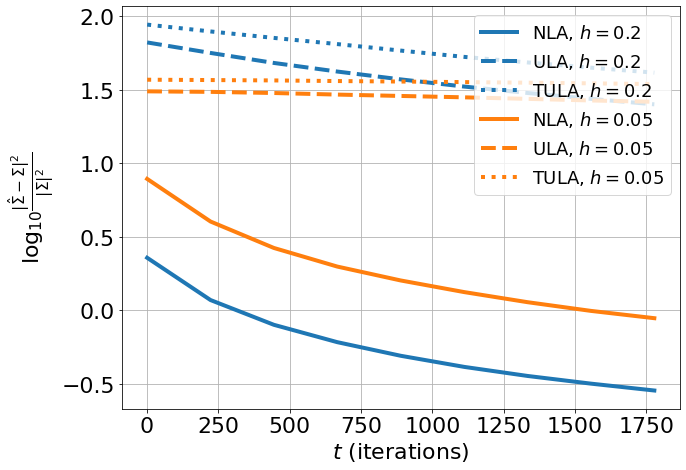

In [196]:
convN = np.load('plot_data/convN_scat.npy')
convL = np.load('plot_data/convL_scat.npy')
convT = np.load('plot_data/convT_scat.npy')

p, ax = plt.subplots(figsize = (10, 7))
iters = np.round(np.linspace(1, N, num))
# itersL = np.round(np.linspace(1, N2, round(N2/(2*d))))

colors = ['tab:blue', "tab:orange"]
i = 0
idx = [0,1]
for i in idx:
    s = steps[i]
    ax.plot(iters, np.log10(convN[:,i]), color = colors[i], linestyle = lts[0], label = r'NLA, $h=$' + s, linewidth = 4)
    ax.plot(iters, np.log10(convL[:,i]), color = colors[i], linestyle = lts[1], label = r'ULA, $h=$' + s, linewidth = 4)
    ax.plot(iters, np.log10(convT[:,i]), color = colors[i], linestyle = lts[3], label = r'TULA, $h=$' + s, linewidth = 4)
    
    i += 1
    
handles, labels = ax.get_legend_handles_labels() 
ax.legend(loc='upper right')
plt.xlabel(r'$t$ (iterations)')    
plt.ylabel(r'$\log_{10} \frac{\|\hat \Sigma - \Sigma\|^2}{\| \Sigma \|^2}$')   
ax.grid(b = True)
plt.tight_layout()
plt.savefig('gen_mvg_cov_iters_legend.pdf')

In [119]:
d

10

In [ ]:
p, ax = plt.subplots(figsize = (10, 7))

colors = ['tab:blue', "tab:olive", "tab:purple", "tab:orange"]
i = 0
idx = [0, 3]
for i in idx:
    s = steps[i]
    ax.plot(np.log10(convN[0:N,i]), color = colors[i], linestyle = lts[0], label = r'NLA, $h=$' + s, linewidth = 4)
    ax.plot(np.log10(convL[0:N,i]), color = colors[i], linestyle = lts[1], label = r'ULA, $h=$' + s, linewidth = 4)
    ax.plot(np.log10(convT[0:N,i]), color = colors[i], linestyle = lts[3], label = r'TULA, $h=$' + s, linewidth = 4)
    
    i += 1
    
handles, labels = ax.get_legend_handles_labels() 
ax.legend()
plt.xlabel(r'$t$ (iterations)')    
plt.ylabel(r'$\log_{10} \|\bar X_t\|^2$')   
ax.grid(b = True)

plt.savefig('mvg_mean_iters.pdf')

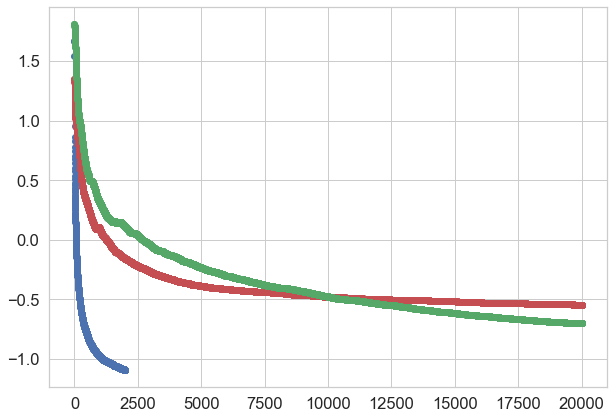

In [26]:
s = '0.7'
YNs = np.load(s + '/' + 'YNs.npy')
YLs = np.load(s + '/' + 'YLs.npy')
YTs = np.load(s + '/' + 'YTs.npy')
Sigma = np.load(s + '/' + 'Sigma.npy')

# Sigma = np.diag(np.linspace(1, 101, d))

reps = 1
d, N, _ = YNs.shape
d, N2, _ = YLs.shape
convL = np.zeros(N2)
convN = np.zeros(N)
convT = np.zeros(N2)
for r in range(reps):
    convN += cov_dist_true(Sigma, YNs[:,:,r]) / reps
    convL += cov_dist_true(Sigma, YLs[:,:,r]) / reps
    convT += cov_dist_true(Sigma, YTs[:,:,r]) / reps
    
p, ax = plt.subplots(figsize = (10, 7))
    
ax.plot(np.log10(convN), 'bo', label = r'NLA, $h=$' + s)
ax.plot(np.log10(convL), 'ro', label = r'ULA, $h=$' + s)
ax.plot(np.log10(convT), 'go', label = r'TULA, $h=$' + s)

In [27]:
lcn = np.log10(convN)
lcl = np.log10(convL)
lct = np.log10(convT)

errors = [1.00, 0.5, -0.0, -0.5]
ieN = np.zeros(len(errors))
ieL = np.zeros(len(errors))
ieT = np.zeros(len(errors))
i = 0
for e in errors:
    ieN[i] = next(x for x, val in enumerate(lcn) if val <e)
    ieL[i] = next(x for x, val in enumerate(lcl) if val <e)
    ieT[i] = next(x for x, val in enumerate(lct) if val <e)
    i += 1
    

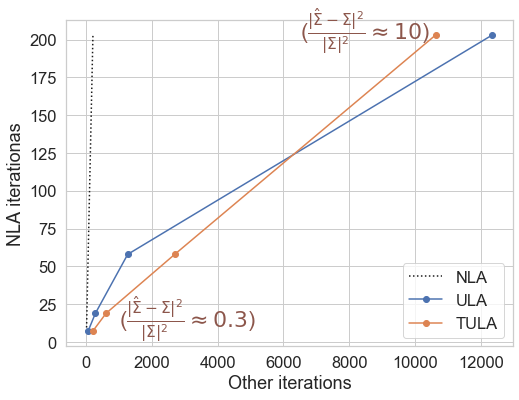

In [38]:


plt.figure(figsize = (8, 6))



plt.plot(ieN, ieN, 'k:')
plt.plot(ieL, ieN, 'o-')
plt.plot(ieT, ieN, 'o-')
plt.legend(['NLA', 'ULA', 'TULA'])
plt.ylabel("NLA iterationas")
plt.xlabel("Other iterations")
plt.text(1000, 10, r'($\frac{\| \hat \Sigma - \Sigma\|^2}{\|\Sigma\|^2} \approx 0.3$)', c = 'tab:brown', fontsize = 22)
plt.text(6500, 200, r'($\frac{\| \hat \Sigma - \Sigma\|^2}{\|\Sigma\|^2} \approx 10$)', c = 'tab:brown', fontsize = 22)

plt.savefig('iter_vs_iter_cov_mvg_07.pdf')

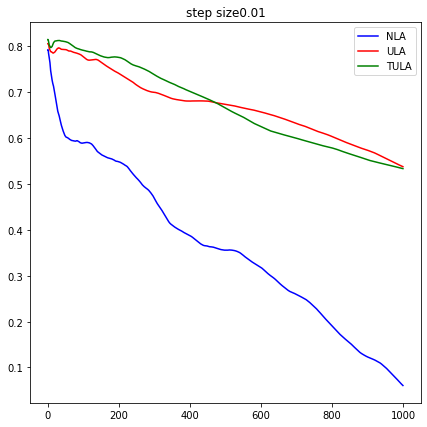

In [50]:
s = '0.01'
YNs = np.load(s + '/' + 'YNs.npy')
YLs = np.load(s + '/' + 'YLs.npy')
YTs = np.load(s + '/' + 'YTs.npy')

reps = 50
convL = np.zeros(1000)
convN = np.zeros(1000)
convT = np.zeros(1000)
for r in range(reps):
    convN += mean_dist_true(np.zeros((5,)), YNs[:,:,r]) / reps
    convL += mean_dist_true(np.zeros((5,)), YLs[:,:,r]) / reps
    convT += mean_dist_true(np.zeros((5,)), YTs[:,:,r]) / reps
    

plt.figure(figsize = (7, 7))
plt.title('step size' + s)
plt.plot(np.log10(convN), 'b')
plt.plot(np.log10(convL), 'r')
plt.plot(np.log10(convT), 'g')
plt.legend(['NLA', 'ULA', 'TULA'])

In [197]:
import math
from scipy.linalg import sqrtm, inv

SMALL_SIZE = 14
MEDIUM_SIZE = 18
BIGGER_SIZE = 22

plt.rc('font', size=MEDIUM_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE) 

In [198]:
s = '0.2'

YNs = np.load(s + '/' + 'YNs.npy')
YLs = np.load(s + '/' + 'YLs.npy')
YTs = np.load(s + '/' + 'YTs.npy')


In [226]:
d, N, reps = YNs.shape
YN = YNs[:,:,0]
YL = YLs[:,:,0]
YT = YTs[:,:,0]


ts = np.linspace(0, math.pi * 2, 100)
xs = np.cos(ts)
ys = np.sin(ts)
directions = 1*np.array([xs, ys]) 

CN = sqrtm(np.cov(YN[[0,99],:])) #- np.outer(np.mean(YNs[:, 499, :], 1), np.ones(500)))
YN2 = ((CN)).dot(directions)#+ np.outer(np.mean(YNs.reshape( d, N * reps), 1), np.ones(100))


CT = sqrtm(np.cov(YN[[0,99],:])) #- np.outer(np.mean(YNs[:, 499, :], 1), np.ones(500)))
YT2 = ((CT)).dot(directions)#+ np.outer(np.mean(YTs.reshape( d, N * reps), 1), np.ones(100))


CL = sqrtm(np.cov(YL[[0,99],:])) #- np.outer(np.mean(YNs[:, 499, :], 1), np.ones(500)))
YL2 = ((CL)).dot(directions)#+ np.outer(np.mean(YNs.reshape( d, N * reps), 1), np.ones(100))

ell = sqrtm(np.diag(Sigma[[0,99],[0,99]])).dot(directions)

scales = np.power(np.linalg.norm(sqrtm(np.diag(Sigma[[0,99],[0,99]])).dot(directions), axis = 0), 1)
ell =  directions * np.outer(np.ones(2,), scales)


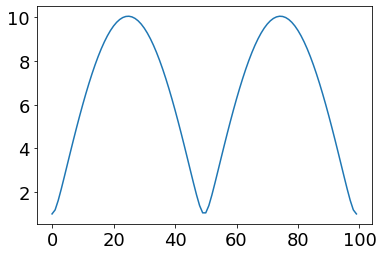

In [223]:
plt.plot(scales)

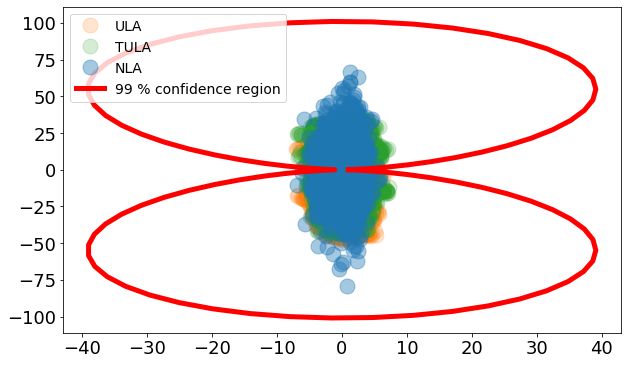

In [225]:
plt.figure(figsize = (10,6))

plt.plot(YL[0,:],YL[-1,:], 'o', color = 'tab:orange', alpha = 0.2, markersize = 15)
plt.plot(YT[0,:],YT[-1,:], 'o', color = 'tab:green', alpha = 0.2, markersize = 15)
plt.plot(YN[0,:],YN[-1,:], 'o', color = 'tab:blue', alpha = 0.4, markersize = 15)
plt.plot(ell[0,:], ell[1,:], 'r', linewidth = 5)

S = np.diag([1,100])
# plt.xlim(-5, 5)

plt.legend(['ULA', 'TULA', 'NLA', '99 % confidence region'])

plt.savefig('gen_mvg_samples_02.pdf')